# PatchTST — CATSA Train → EmpaticaE4 Test (EDA only)

**Model**: PatchTST (Patch Time Series Transformer)
- EDA 240샘플을 patch_len=16, stride=8 → 29패치로 분할
- 각 패치를 토큰으로 Transformer 인코더 처리 (단변량)

**학습**: CATSA 전체 피험자 (EDA 1채널, 4Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

In [1]:
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

TASKS        = ["Baseline","Logic","Nback","Stroop","Sudoku"]
STRESS_TASKS = {"Logic","Nback","Stroop","Sudoku"}
EDA_FS       = 4

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/EDA/Save_model_PatchTST")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def discover_subjects(root):
    out=[]
    for d in sorted(root.glob("Sub*"),key=lambda p:int(p.name[3:])):
        if d.is_dir() and all((d/t/"EDA.csv").exists() for t in TASKS): out.append(d.name)
    return out

def read_eda(path):
    df=pd.read_csv(path); nc=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    vals=df[nc[0]].to_numpy(np.float32) if nc else pd.to_numeric(df.iloc[:,0],errors='coerce').to_numpy(np.float32)
    return vals[~np.isnan(vals)]

def make_windows_1d(sig,W,S):
    if len(sig)<W: return np.empty((0,1,W),np.float32)
    return np.asarray([sig[i:i+W] for i in range(0,len(sig)-W+1,S)],np.float32)[:,None,:]

def build_catsa_arrays(subjects,W,S):
    xs,ys=[],[]
    for sub in subjects:
        path=CATSA_ROOT/sub
        all_v=np.concatenate([read_eda(path/t/"EDA.csv") for t in TASKS])
        mu=float(np.mean(all_v)); sigma=float(np.std(all_v))+1e-8
        for task in TASKS:
            norm=(read_eda(path/task/"EDA.csv")-mu)/sigma
            w=make_windows_1d(norm,W,S)
            if len(w): xs.append(w); ys.append(np.full(len(w),int(task in STRESS_TASKS),np.int64))
    return np.concatenate(xs),np.concatenate(ys)

def build_e4_labels(n,fs=4):
    fixed_s={"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
             "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    task4_s=max(0,n//fs-sum(fixed_s.values()))
    segs=[("rest0",180,0),("task1",600,1),("rest1",120,-1),("task2",300,1),
          ("rest2",120,-1),("task3",180,1),("rest3",120,-1),("task4",task4_s,1),
          ("rest4",120,-1),("task5",60,1),("rest5",120,-1)]
    labels=np.full(n,-1,np.int64); cur=0
    for _,dur_s,lab in segs:
        end=min(cur+dur_s*fs,n)
        if end>cur: labels[cur:end]=lab
        cur=end
        if cur>=n: break
    return labels,int(task4_s)

def e4_windows(eda,labels,W,S):
    mask=labels>=0
    mu=float(np.mean(eda[mask])) if mask.any() else float(np.mean(eda))
    sigma=(float(np.std(eda[mask]))+1e-8) if mask.any() else (float(np.std(eda))+1e-8)
    norm=((eda-mu)/sigma).astype(np.float32)
    xs,ys=[],[]
    for i in range(0,len(norm)-W+1,S):
        u=np.unique(labels[i:i+W])
        if len(u)==1 and u[0] in (0,1): xs.append(norm[i:i+W]); ys.append(int(u[0]))
    if not xs: return np.empty((0,1,W),np.float32),np.empty(0,np.int64)
    return np.asarray(xs,np.float32)[:,None,:],np.asarray(ys,np.int64)

class FocalLoss(nn.Module):
    def __init__(self,gamma=2.0,alpha=None): super().__init__(); self.gamma,self.alpha=gamma,alpha
    def forward(self,logits,y):
        y=y.float(); bce=F.binary_cross_entropy_with_logits(logits,y,reduction="none")
        pt=torch.sigmoid(logits)*y+(1-torch.sigmoid(logits))*(1-y)
        fl=(1-pt).pow(self.gamma)*bce
        if self.alpha is not None: fl=(self.alpha*y+(1-self.alpha)*(1-y))*fl
        return fl.mean()

def make_loader(x,y,bs,shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(x),torch.from_numpy(y).float()),batch_size=bs,shuffle=shuffle)

@torch.no_grad()
def evaluate(model,loader,criterion):
    model.eval(); tot=n=tp=tn=fp=fn=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); lg=model(xb)
        tot+=criterion(lg,yb).item()*len(xb); n+=len(xb)
        pred=(torch.sigmoid(lg)>=0.5).long(); yi=yb.long()
        tp+=int(((pred==1)&(yi==1)).sum()); tn+=int(((pred==0)&(yi==0)).sum())
        fp+=int(((pred==1)&(yi==0)).sum()); fn+=int(((pred==0)&(yi==1)).sum())
    acc=(tp+tn)/max(n,1); pre=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":2*pre*rec/max(pre+rec,1e-8),
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch(model,loader,optimizer,criterion):
    model.train(); tot=n=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True); loss=criterion(model(xb),yb); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        tot+=loss.item()*len(xb); n+=len(xb)
    return tot/max(n,1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [2]:
# ── PatchTST Model (EDA — univariate) ─────────────────────────────────────
class PatchTSTClassifier(nn.Module):
    """
    PatchTST for univariate EDA.
    240-sample window → (240-16)//8+1 = 29 patches of length 16.
    Each patch is a token; standard Transformer processes the patch sequence.
    """
    def __init__(self, seq_len: int = 240, patch_len: int = 16, patch_stride: int = 8,
                 d_model: int = 128, n_heads: int = 8, n_layers: int = 3,
                 d_ff: int = 256, dropout: float = 0.1):
        super().__init__()
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
        self.d_model      = d_model
        n_patches         = (seq_len - patch_len) // patch_stride + 1
        self.n_patches    = n_patches

        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)
        self.norm_in     = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, 240]
        x_sq    = x.squeeze(1)                                  # [B, 240]
        patches = x_sq.unfold(-1, self.patch_len, self.patch_stride)  # [B, n_patches, patch_len]
        tokens  = self.norm_in(self.patch_embed(patches) + self.pos_embed)  # [B, n_patches, d_model]
        out     = self.transformer(tokens).mean(dim=1)          # [B, d_model]
        return self.head(out).squeeze(-1)                       # [B]

model_test = PatchTSTClassifier()
print(f"Output: {model_test(torch.randn(4,1,240)).shape}  n_patches={model_test.n_patches}")
print(f"Trainable params: {sum(p.numel() for p in model_test.parameters() if p.requires_grad):,}")
del model_test

Output: torch.Size([4])  n_patches=29
Trainable params: 412,161


In [3]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"        :42,"val_ratio":0.10,
    "window_size" :EDA_FS*60,"stride":EDA_FS*10,
    "batch_size"  :64,"epochs":50,"lr":1e-3,"wd":1e-4,"patience":8,
    "patch_len"   :16,"patch_stride":8,
    "d_model"     :128,"n_heads":8,"n_layers":3,"d_ff":256,"dropout":0.1,
}

np.random.seed(HP["seed"]); torch.manual_seed(HP["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(HP["seed"])

subjects  = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")
rng=np.random.default_rng(HP["seed"]); idx=rng.permutation(len(subjects))
n_val=max(4,int(len(subjects)*HP["val_ratio"]))
val_subs=[subjects[i] for i in sorted(idx[:n_val])]
train_subs=[subjects[i] for i in sorted(idx[n_val:])]
print(f"Train:{len(train_subs)} | Val:{len(val_subs)}")

W,S=HP["window_size"],HP["stride"]
print("Building arrays..."); x_train,y_train=build_catsa_arrays(train_subs,W,S)
x_val,y_val=build_catsa_arrays(val_subs,W,S)
print(f"Train:{x_train.shape}  Val:{x_val.shape}")

loader_tr=make_loader(x_train,y_train,HP["batch_size"],True)
loader_va=make_loader(x_val,y_val,HP["batch_size"],False)
pos=float(y_train.sum()); alpha=float((len(y_train)-pos)/len(y_train))
criterion=FocalLoss(gamma=2.0,alpha=alpha).to(DEVICE)

model=PatchTSTClassifier(
    seq_len=W,patch_len=HP["patch_len"],patch_stride=HP["patch_stride"],
    d_model=HP["d_model"],n_heads=HP["n_heads"],n_layers=HP["n_layers"],
    d_ff=HP["d_ff"],dropout=HP["dropout"]).to(DEVICE)

optimizer=torch.optim.Adam(model.parameters(),lr=HP["lr"],weight_decay=HP["wd"])
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,"min",factor=0.5,patience=4)
best_val_loss=float("inf"); best_state=None; wait=0; history=[]

for epoch in range(1,HP["epochs"]+1):
    tr_loss=train_epoch(model,loader_tr,optimizer,criterion)
    val_m=evaluate(model,loader_va,criterion); scheduler.step(val_m["loss"])
    history.append({"epoch":epoch,"train_loss":tr_loss,"val_loss":val_m["loss"],"val_f1":val_m["f1"]})
    if val_m["loss"]<best_val_loss:
        best_val_loss=val_m["loss"]; best_epoch=epoch; wait=0
        best_state=deepcopy(model.state_dict())
        torch.save({"model_state_dict":best_state,"hp":HP,"epoch":epoch},SAVE_DIR/"best_model.pt")
    else:
        wait+=1
        if wait>=HP["patience"]: print(f"Early stopping at epoch {epoch} (best:{best_epoch})"); break
    if epoch%5==0 or epoch==1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  f1={val_m['f1']:.4f}")

model.load_state_dict(best_state)
print(f"\nDone. Best epoch:{best_epoch}, best_val_loss:{best_val_loss:.4f}")

Total CATSA subjects: 50
Train:45 | Val:5
Building arrays...
Train:(2925, 1, 240)  Val:(325, 1, 240)
[  1] train=0.0449  val=0.0301  f1=0.9150
[  5] train=0.0403  val=0.0275  f1=0.9467
[ 10] train=0.0388  val=0.0260  f1=0.9132
Early stopping at epoch 15 (best:7)

Done. Best epoch:7, best_val_loss:0.0253


In [4]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval(); all_true,all_pred=[],[]; rows=[]
for sub in SUBJECTS_E4:
    eda=read_eda(E4_ROOT/sub/"EDA.csv"); labels,task4_sec=build_e4_labels(len(eda))
    x,y_true=e4_windows(eda,labels,W,S)
    if len(x)==0:
        rows.append({"subject":sub,"n_windows":0,"accuracy":float("nan"),
                     "f1":float("nan"),"precision":float("nan"),"recall":float("nan")}); continue
    with torch.no_grad():
        logits=model(torch.from_numpy(x).to(DEVICE))
        y_pred=(torch.sigmoid(logits)>=0.5).cpu().numpy().astype(int)
    rows.append({"subject":sub,"task4_sec":task4_sec,"n_windows":len(y_true),
                 "accuracy":float(accuracy_score(y_true,y_pred)),
                 "f1":float(f1_score(y_true,y_pred,zero_division=0)),
                 "precision":float(precision_score(y_true,y_pred,zero_division=0)),
                 "recall":float(recall_score(y_true,y_pred,zero_division=0))})
    all_true.extend(y_true.tolist()); all_pred.extend(y_pred.tolist())

result_df=pd.DataFrame(rows); print("=== Per-subject ==="); display(result_df)
if all_true:
    ov_acc=accuracy_score(all_true,all_pred); ov_f1=f1_score(all_true,all_pred,zero_division=0)
    ov_prec=precision_score(all_true,all_pred,zero_division=0); ov_rec=recall_score(all_true,all_pred,zero_division=0)
    print(f"\nOverall — Acc:{ov_acc:.4f}  F1:{ov_f1:.4f}  Prec:{ov_prec:.4f}  Rec:{ov_rec:.4f}")
    cm=confusion_matrix(all_true,all_pred); print(cm)
    print(classification_report(all_true,all_pred,target_names=["Non-stress","Stress"],zero_division=0))

=== Per-subject ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,584,159,0.905660,0.945848,1.000000,0.897260
1,subject_02,434,144,0.743056,0.835556,1.000000,0.717557
2,subject_03,0,75,0.733333,0.814815,0.956522,0.709677
3,subject_04,0,106,0.773585,0.851852,1.000000,0.741935
4,subject_05,163,117,0.726496,0.818182,1.000000,0.692308
5,subject_06,0,68,0.823529,0.886792,0.921569,0.854545



Overall — Acc:0.7907  F1:0.8672  Prec:0.9870  Rec:0.7733
[[ 72   6]
 [134 457]]
              precision    recall  f1-score   support

  Non-stress       0.35      0.92      0.51        78
      Stress       0.99      0.77      0.87       591

    accuracy                           0.79       669
   macro avg       0.67      0.85      0.69       669
weighted avg       0.91      0.79      0.83       669



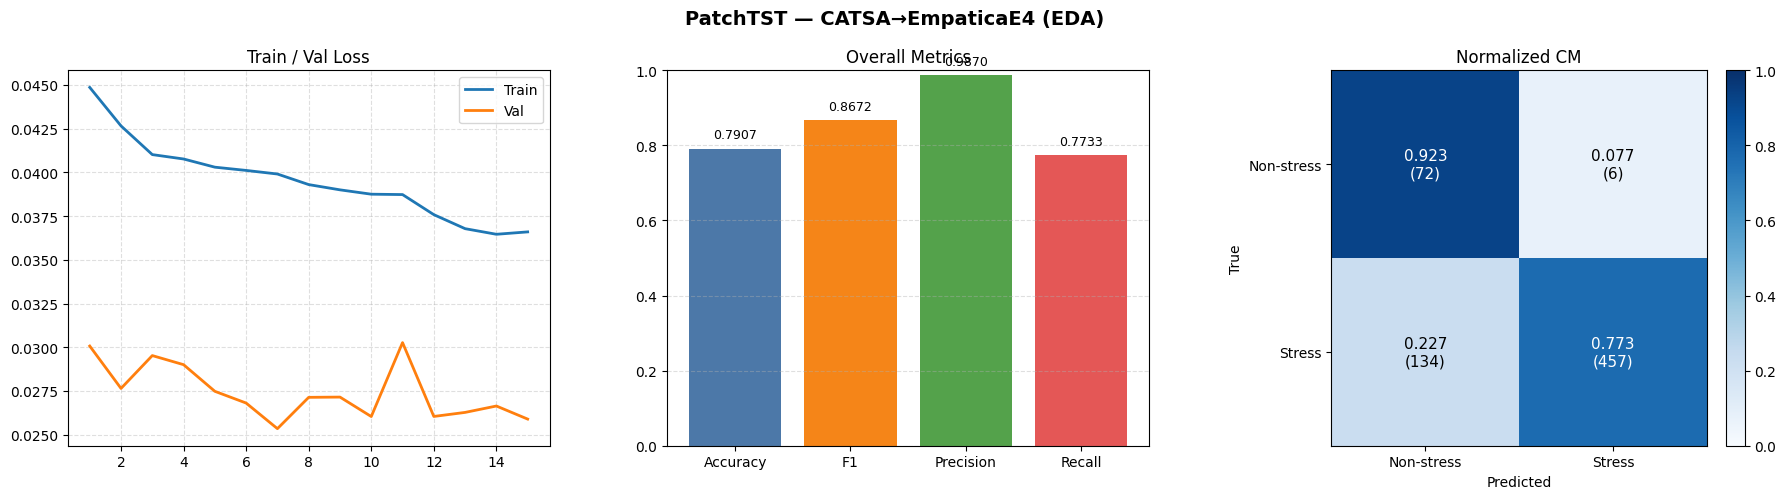

Saved results.png


In [5]:
# ── Visualization ─────────────────────────────────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].plot([h["epoch"] for h in history],[h["train_loss"] for h in history],label="Train",linewidth=2)
axes[0].plot([h["epoch"] for h in history],[h["val_loss"]   for h in history],label="Val",  linewidth=2)
axes[0].set_title("Train / Val Loss"); axes[0].legend(); axes[0].grid(linestyle="--",alpha=0.4)
if all_true:
    bars=axes[1].bar(["Accuracy","F1","Precision","Recall"],[ov_acc,ov_f1,ov_prec,ov_rec],
                     color=["#4C78A8","#F58518","#54A24B","#E45756"])
    axes[1].set_ylim(0,1); axes[1].set_title("Overall Metrics")
    axes[1].grid(axis="y",linestyle="--",alpha=0.4)
    for b,v in zip(bars,[ov_acc,ov_f1,ov_prec,ov_rec]):
        axes[1].text(b.get_x()+b.get_width()/2,v+0.02,f"{v:.4f}",ha="center",va="bottom",fontsize=9)
    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True).clip(1)
    im=axes[2].imshow(cm_norm,cmap="Blues",vmin=0,vmax=1)
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"]); axes[2].set_yticklabels(["Non-stress","Stress"])
    axes[2].set_title("Normalized CM"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    thr=cm_norm.max()/2
    for i in range(2):
        for j in range(2):
            axes[2].text(j,i,f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",ha="center",va="center",
                         color="white" if cm_norm[i,j]>thr else "black",fontsize=11)
    fig.colorbar(im,ax=axes[2],fraction=0.046,pad=0.04)
fig.suptitle("PatchTST — CATSA→EmpaticaE4 (EDA)",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.savefig(SAVE_DIR/"results.png",dpi=150,bbox_inches="tight"); plt.show()
print("Saved results.png")